In [1]:
import os
import json
import time
import argparse
from typing import Tuple, Optional
import re

import numpy as np
from scipy.optimize import minimize

#few and SEF imports
from few.waveform import GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import KerrEccEqFlux
from few.utils.geodesic import get_fundamental_frequencies
from scipy.interpolate import CubicSpline
from scipy.integrate import cumulative_trapezoid
from few.utils.constants import MTSUN_SI

from fastlisaresponse import ResponseWrapper
from lisatools.detector import EqualArmlengthOrbits
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from stableemrifisher.utils import generate_PSD, inner_product
from stableemrifisher.fisher import StableEMRIFisher
import matplotlib.pyplot as plt

from config_paris import Config, ObjectiveTracker
from misc import *
try:
    import cupy as cp
    xp=cp
except:
    xp=np
    print("CuPy not found, using NumPy instead. For GPU acceleration, please install CuPy.")

from inference import  prepare_true_waveform

startup


# GENERAL RESULTS FOR EMRI CASE:

EMRI PARARMS: theta0: [1000000.0, 10.0, 0.9, 7.5, 0.5, 0.7853981633974483, 1.0, 0.9, 0.4]
SNR :

## 1 PA best fit points : 
	

	final_overlap: 183.28826185751265 
	x:  [999894.8642202921, 9.99920420648945, 0.8999403453809112, 7.500388327250165, 0.5000214239573864, 0.7911480317189448, 1.0103259434845695, 1.0674573624561179, 0.3675966046004827]

read log files for recent two runs ig

## 0 PA best fit (BF) points 
	
	Overlap of the best point: 183.28595232649386
	Best point : [1000117.4489066871, 10.000747713536276, 0.9000821275834304, 7.499521999767378, 0.49998410573186125, 0.7832871364017695, 1.010973741062668, 1.0747886916109437, 0.38364873884565026]

## 1 PA dev

	intial overlap will be same as 0pa best fit case
	final overlap: 183.2786655123872
	x_best_fit = [1000000.0, 10.000000009924808, 0.8999997959803092, 7.499999983316402, 0.5000000389251131, 0.7853981634909842, 0.9999999999362225, 0.9000000000576618, 0.3999999999899322, 1.0000000307877215, 0.9999998929309868]

[INFO] Finished loading modules and building ResponseWrapper
[INFO] Finished generating true waveform
shape check - waveform_true: (3, 3155814) PSD_funcs: (3, 1577907)
[TRUE] SNR: 184.186765
[TRUE] SNR - Channel 0: 28.590175
[TRUE] SNR - Channel 1: 24.933803
[TRUE] SNR - Channel 2: 180.237820
[INFO] Frequency resolution delta_f: 3.168755e-08 Hz, Number of frequency bins: 1577908
freq_max: 0.050000 Hz and Freq_min: 0.000000 Hz


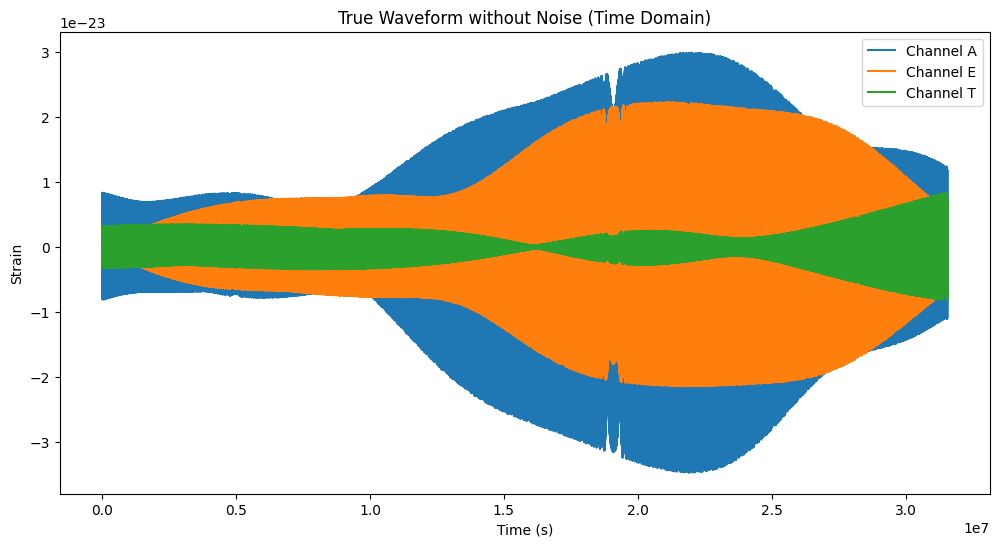

[INFO] Added noise to true waveform FFT

shape of waveform_true_fft after noise addition: (3, 1577907)


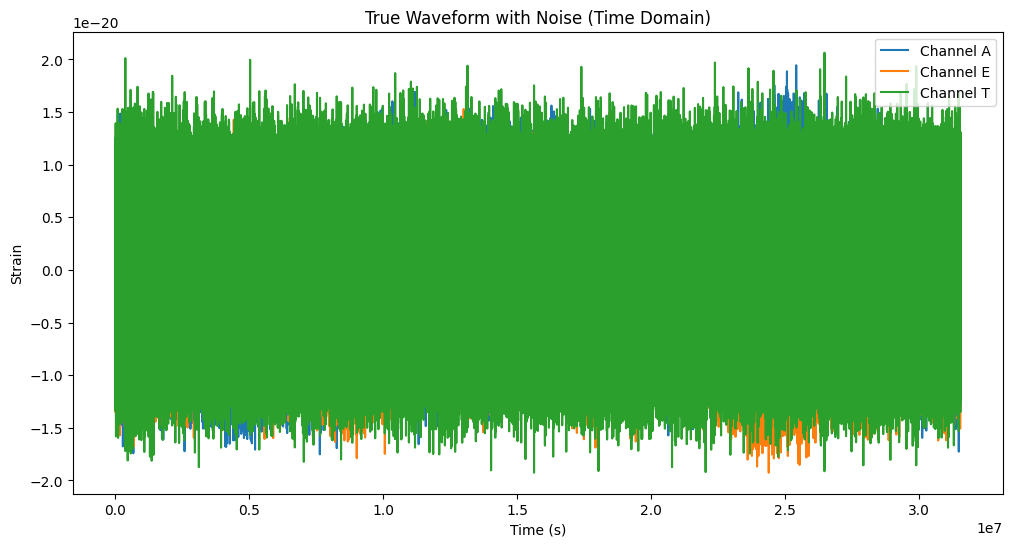

Length of PSD: 1577907


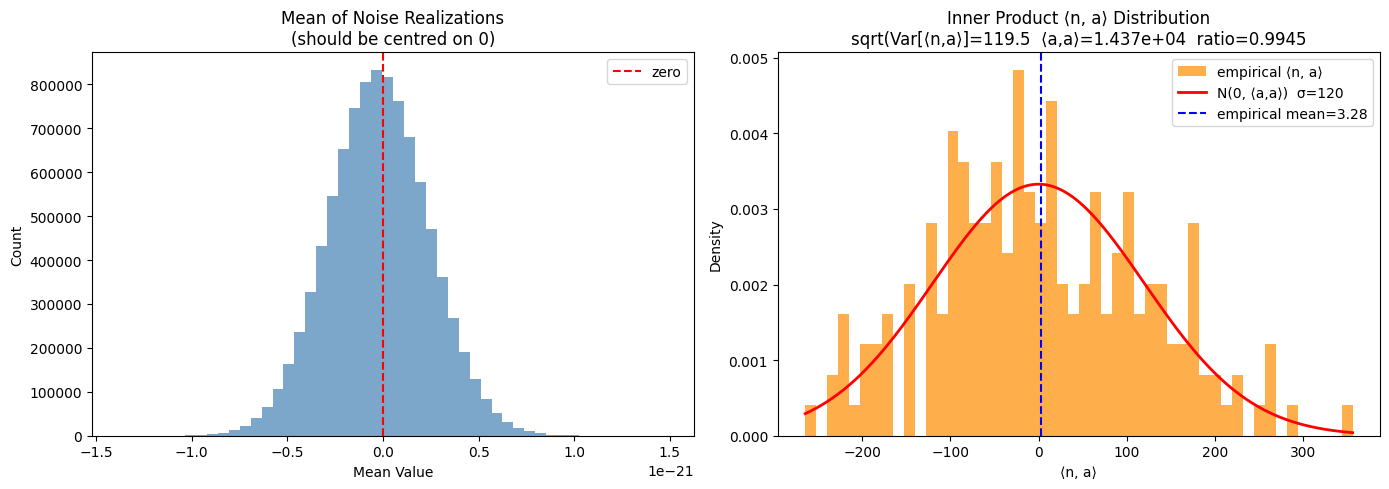

  Noise model consistency check
  Backend                : CuPy (GPU)
  Realizations           : 200
  N time samples         : 3155812  |  PSD bins passed: 1577906
  N (template samples)   : 3155814  →  aligned to 3155812
  Max |mean noise|       : 1.4832e-21  (expect ≈ 0)
  E[⟨n, a⟩]             : 3.2804e+00           (expect ≈ 0)
  Var[⟨n, a⟩]           : 14287.8
  ⟨a, a⟩                : 14367.1
  Ratio Var/⟨a,a⟩       : 0.994484          (expect ≈ 1.0)
Noise consistency check results: {'mean_noise': array([[-3.08572637e-22,  5.21234944e-22, -3.09194809e-22, ...,
        -2.71103137e-22,  2.98321182e-22,  2.02109510e-22],
       [ 5.50421568e-23, -1.07322797e-22,  3.25350610e-22, ...,
        -2.30612469e-22,  2.31649956e-22,  2.19601881e-22],
       [-3.24760315e-22,  9.12728428e-23,  3.47851399e-23, ...,
        -2.56312609e-22, -3.72123314e-22,  5.36292394e-22]],
      shape=(3, 3155812)), 'inner_products': array([ 202.77357066, -194.17222559,  -52.51708988, -173.73790148,
     

{'m1': np.float64(1000000.0),
 'm2': np.float64(10.0),
 'a': np.float64(0.9),
 'p0': np.float64(7.5),
 'e0': np.float64(0.5),
 'Y0': np.float64(1.0),
 'dist': np.float64(5.0),
 'qS': np.float64(0.7853981633974483),
 'phiS': np.float64(1.0),
 'qK': np.float64(1.0),
 'phiK': np.float64(1.0471975511965976),
 'Phi_phi0': np.float64(0.9),
 'Phi_theta0': np.float64(0.5),
 'Phi_r0': np.float64(0.4),
 'dt': 10,
 'T': 1.0,
 'chi2': 0.0,
 'dev_1': 1.0,
 'dev_2': 1.0,
 'waveform_response': <fastlisaresponse.response.ResponseWrapper at 0x155254dcf3e0>,
 'PSD_funcs': array([[6.81763434e-35, 1.70440862e-35, 7.57514968e-36, ...,
         1.61311193e-40, 1.61310358e-40, 1.61309523e-40],
        [6.81763434e-35, 1.70440862e-35, 7.57514968e-36, ...,
         1.61311193e-40, 1.61310358e-40, 1.61309523e-40],
        [2.65994853e-56, 1.06395802e-55, 2.39388950e-55, ...,
         5.36070468e-40, 5.36068302e-40, 5.36066135e-40]],
       shape=(3, 1577907)),
 'waveform_true_fft': array([[-6.25689796e-15-2.560

In [9]:
seed= 42   
param_names_to_infer = ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0']  
params_name = ["m1","m2","a","p0","e0","xI0","dist","qS","phiS","qK","phiK",
                         "Phi_phi0","Phi_theta0","Phi_r0"]      

params = np.array([1e6,1e1,0.9, 7.5,  5.00000000e-01,  1.00000000e+00,
          5.0,  np.pi/4,  1.0, 1,  np.pi/3,  9.00000000e-01, 5.00000000e-01,  4.00000000e-01])

signal_param = {"m1": 1e6,
    "m2": 10.0,
    "a": 0.9,
    "p0": 7.5,
    "e0": 0.5,
    "xI0": 1.0,
    "dist": 5.0,
    "qS": np.pi/4,
    "phiS": 1,
    "qK": 1,
    "phiK": np.pi/3,
    "Phi_phi0": 0.9,
    "Phi_theta0": 0.5,
    "Phi_r0": 4.00000000e-01,
}
signal_param_array = np.array(list(signal_param.values()))
dt = 10  #Time step for waveform generation; default 0.1s
T= 1.0

chi2 = 0.0 
dev_1 = 1.0
dev_2 = 1.0

emri_kwargs = {"T": T, "dt": dt,'chi2': chi2,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': dev_1, 'dev_2': dev_2}
add_kwargs = {'chi2': chi2,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': dev_1, 'dev_2': dev_2}

# if target_func in ('optimal_snr', 'optimal_snr_phase_max','time_max'):
        
ctx = prepare_true_waveform(signal_param_array, emri_kwargs, add_kwargs,add_noise=True, use_gpu=True,seed=seed)

snr_2 = inner_prod(ctx['waveform_true_fft_without_noise'], ctx['waveform_true_fft_without_noise'], ctx['PSD_funcs'], ctx['delta_f'], xp=xp)
ctx

# Overlap with Noise and With True Signal Without Noise

In [10]:
noise_f =  ctx['noise']
Respsone = ctx['waveform_response']


## 1PA best fit

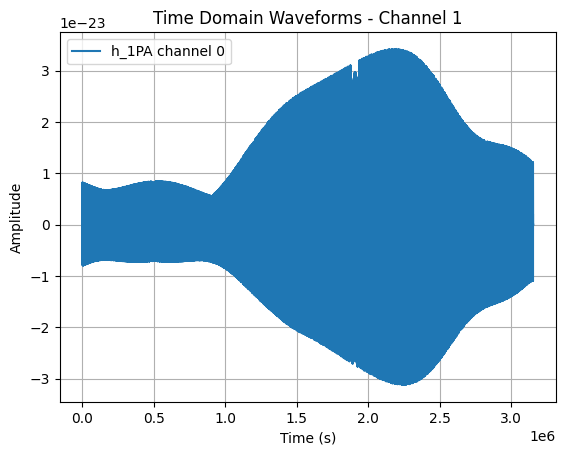

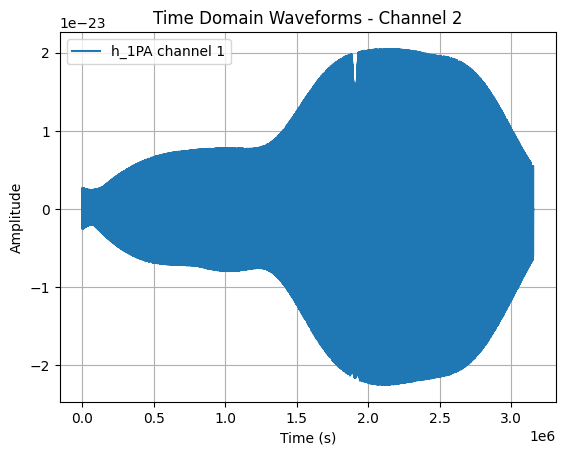

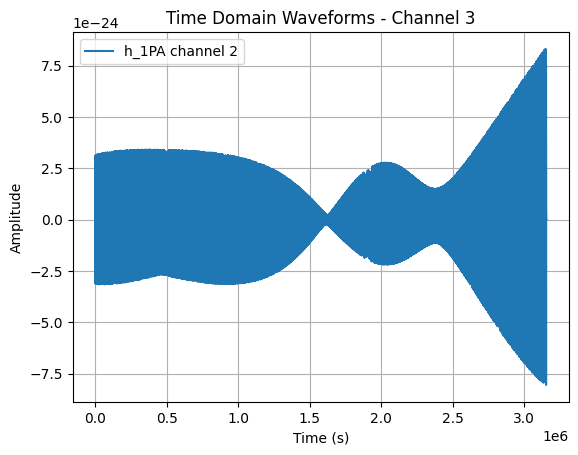

noise inner product with 1PA: -159.26868548059832
square of overlap in each channel 1: 28.616587975196445
square of overlap in each channel 2: 24.95579920907084
square of overlap in each channel 3: 178.11670542927436
detection SNR for noise: -0.8843942875095488
Actual overlap: 182.1188122476218
detection SNR using true waveform: 184.17265614502224
detection SNR using actual signal: 183.2882618575127


In [11]:
x_best_fit_1PA =  [999894.8642202921, 9.99920420648945, 0.8999403453809112, 7.500388327250165, 0.5000214239573864, 0.7911480317189448, 1.0103259434845695, 1.0674573624561179, 0.3675966046004827]
add_kwargs = {'chi2': 0,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': 1, 'dev_2': 1}

m1, m2, a, p0, e0,qS,phiS,Phi_phi0,Phi_r0 = x_best_fit_1PA
wave_params = [m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],qS,phiS, ctx['qK'], ctx['phiK'], 
                    Phi_phi0, ctx['Phi_theta0'], Phi_r0,add_kwargs['chi2'],add_kwargs['evolve_1PA'],add_kwargs['evolve_primary'],
                    add_kwargs['evolve_2PA'], add_kwargs['deviation_included'],add_kwargs['dev_1'],add_kwargs['dev_2']]
emri_kwargs =  {"T": ctx['T'], "dt": ctx['dt'],'chi2': add_kwargs['chi2'],'evolve_1PA': add_kwargs['evolve_1PA'],
                    'evolve_primary': add_kwargs['evolve_primary'],'evolve_2PA': add_kwargs['evolve_2PA'],'deviation_included': add_kwargs['deviation_included'],
               'dev_1': add_kwargs['dev_1'], 'dev_2': add_kwargs['dev_2']}
h_1PA = xp.array(Respsone(*wave_params, **emri_kwargs))
for i in range(3):
    plt.plot(h_1PA[i].get(), label=f"h_1PA channel {i}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title(f"Time Domain Waveforms - Channel {i+1}")
    plt.legend()
    plt.grid()
    plt.show()
h_1PA_f = compute_fft_with_windowing(h_1PA, ctx['dt'], ctx['N_fiducial'],type=None,use_gpu=True,n_channels=3)
n_hf = inner_prod(h_1PA_f, noise_f, ctx['PSD_funcs'], ctx['delta_f'], xp=xp)
print("noise inner product with 1PA:", n_hf)
optimal_snr_h_1PA = inner_prod(h_1PA_f, h_1PA_f, ctx['PSD_funcs'], ctx['delta_f'], xp=xp
                               )
for i in range(3):
    print(f"square of overlap in each channel {i+1}:", np.sqrt(inner_prod(h_1PA_f[i], ctx['waveform_true_fft_without_noise'][i], ctx['PSD_funcs'][i], ctx['delta_f'], xp=xp)))

print("detection SNR for noise:", n_hf/np.sqrt(optimal_snr_h_1PA))

actual_overlap = inner_prod(ctx['waveform_true_fft_without_noise'], h_1PA_f, ctx['PSD_funcs'], ctx['delta_f'], xp=xp)
print("Actual overlap:", np.sqrt(actual_overlap))
print("detection SNR using true waveform:", actual_overlap/np.sqrt(optimal_snr_h_1PA))
print("detection SNR using actual signal:", actual_overlap/np.sqrt(optimal_snr_h_1PA)  + n_hf/np.sqrt(optimal_snr_h_1PA))

## 0PA best fit

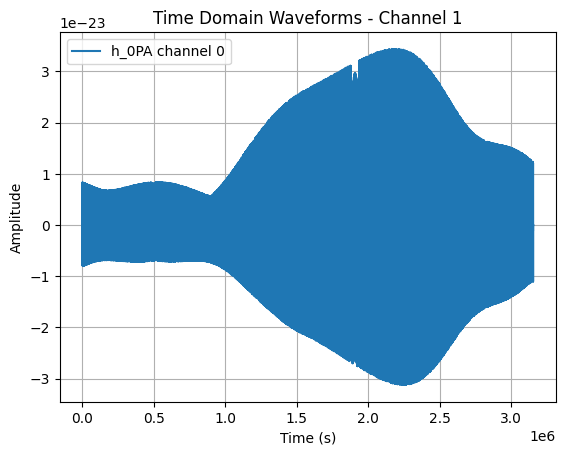

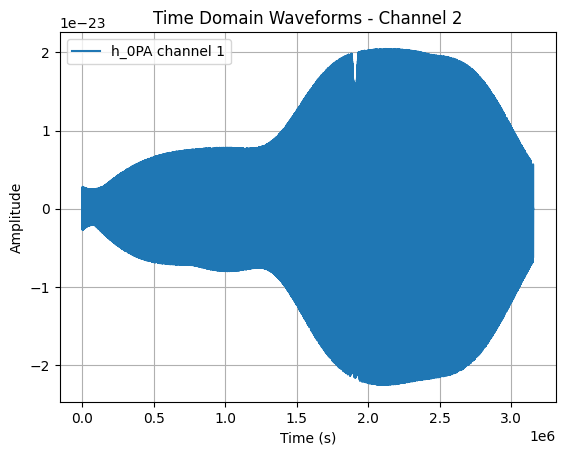

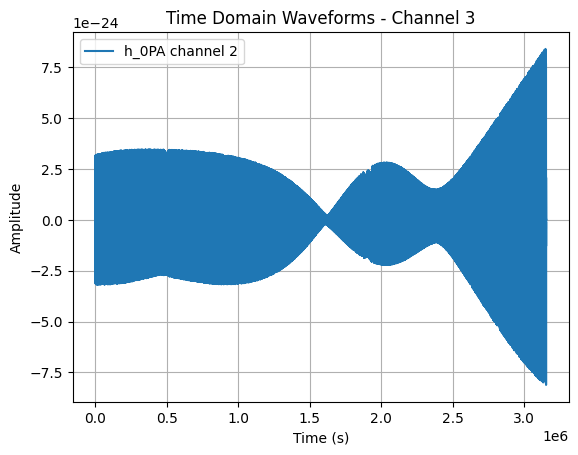

square of overlap in each channel 1: 28.589167418328714
square of overlap in each channel 2: 24.933020118906512
square of overlap in each channel 3: 178.02918932414892
noise inner product with 0PA: -159.58467737721492
detection SNR -0.8870565846797649
Actual overlap: 182.0257900335463
detection SNR using true waveform: 184.17300891117364
detection SNR using actual signal: 183.28595232649388


In [12]:
x_best_fit_0PA =  [1000117.4489066871, 10.000747713536276, 0.9000821275834304, 7.499521999767378, 0.49998410573186125, 0.7832871364017695, 1.010973741062668, 1.0747886916109437, 0.38364873884565026]
add_kwargs = {'chi2': 0,'evolve_1PA': False,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': 0, 'dev_2': 0}

m1, m2, a, p0, e0,qS,phiS,Phi_phi0,Phi_r0 = x_best_fit_0PA
wave_params = [m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],qS,phiS, ctx['qK'], ctx['phiK'], 
                    Phi_phi0, ctx['Phi_theta0'], Phi_r0,add_kwargs['chi2'],add_kwargs['evolve_1PA'],add_kwargs['evolve_primary'],
                    add_kwargs['evolve_2PA'], add_kwargs['deviation_included'],add_kwargs['dev_1'],add_kwargs['dev_2']]

emri_kwargs =  {"T": ctx['T'], "dt": ctx['dt'],'chi2': add_kwargs['chi2'],'evolve_1PA': add_kwargs['evolve_1PA'],
                    'evolve_primary': add_kwargs['evolve_primary'],'evolve_2PA': add_kwargs['evolve_2PA'],'deviation_included': add_kwargs['deviation_included'],
               'dev_1': add_kwargs['dev_1'], 'dev_2': add_kwargs['dev_2']}

h_0PA = xp.array(Respsone(*wave_params, **emri_kwargs))
for i in range(3):
    plt.plot(h_0PA[i].get(), label=f"h_0PA channel {i}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title(f"Time Domain Waveforms - Channel {i+1}")
    plt.legend()
    plt.grid()
    plt.show()
h_0PA_f = compute_fft_with_windowing(h_0PA, ctx['dt'], ctx['N_fiducial'],type=None,use_gpu=True,n_channels=3)
n_hf = inner_prod(h_0PA_f, noise_f, ctx['PSD_funcs'], ctx['delta_f'], xp=xp)

for i in range(3):
    print(f"square of overlap in each channel {i+1}:", np.sqrt(inner_prod(h_0PA_f[i], ctx['waveform_true_fft_without_noise'][i], ctx['PSD_funcs'][i], ctx['delta_f'], xp=xp)))
    
print("noise inner product with 0PA:", n_hf)
optimal_snr_h_0PA = inner_prod(h_0PA_f, h_0PA_f, ctx['PSD_funcs'], ctx['delta_f'], xp=xp
                               )
print("detection SNR", n_hf/np.sqrt(optimal_snr_h_0PA))

actual_overlap = inner_prod(ctx['waveform_true_fft_without_noise'], h_0PA_f, ctx['PSD_funcs'], ctx['delta_f'], xp=xp)
print("Actual overlap:", np.sqrt(actual_overlap))
print("detection SNR using true waveform:", actual_overlap/np.sqrt(optimal_snr_h_0PA))
print("detection SNR using actual signal:", actual_overlap/np.sqrt(optimal_snr_h_0PA)  + n_hf/np.sqrt(optimal_snr_h_0PA))

## 0PA best fit + deviation

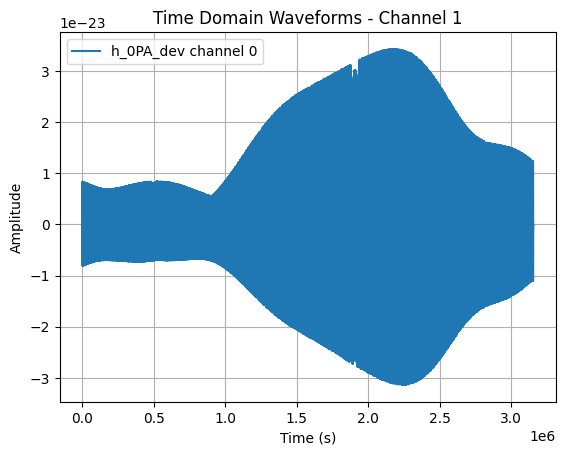

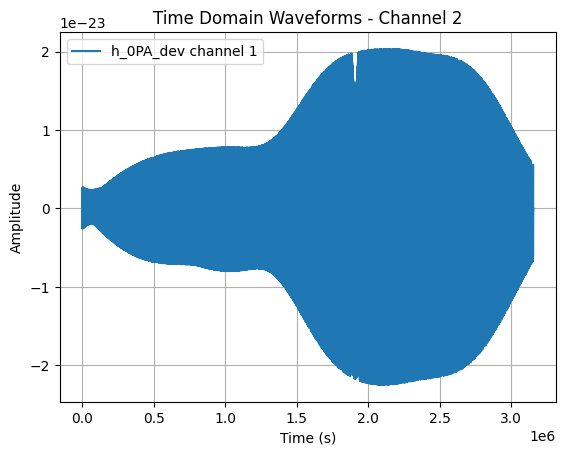

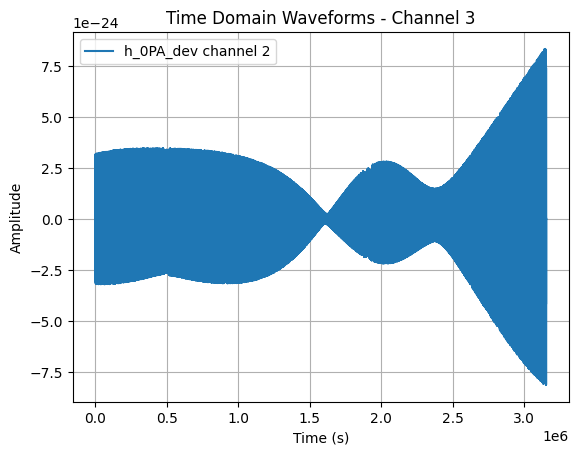

square of overlap in each channel 1: 28.588917408754725
square of overlap in each channel 2: 24.933057443635377
square of overlap in each channel 3: 177.33440130884338
noise inner product with 0PA: -160.99050208347083
detection SNR -0.9016253308870028
Actual overlap: 181.34628046821953
detection SNR using true waveform: 184.1802908432742
detection SNR using actual signal: 183.2786655123872


In [13]:
x_best_fit_0PA_dev =  [1000000.0, 10.000000009924808, 0.8999997959803092, 7.499999983316402, 0.5000000389251131, 0.7853981634909842, 0.9999999999362225, 0.9000000000576618, 0.3999999999899322, 1.0000000307877215, 0.9999998929309868]
add_kwargs = {'chi2': 0,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': x_best_fit_0PA_dev[-2], 'dev_2': x_best_fit_0PA_dev[-1]}

m1, m2, a, p0, e0,qS,phiS,Phi_phi0,Phi_r0,dev_1,dev_2 = x_best_fit_0PA_dev

wave_params = [m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],qS,phiS, ctx['qK'], ctx['phiK'], 
                    Phi_phi0, ctx['Phi_theta0'], Phi_r0,add_kwargs['chi2'],add_kwargs['evolve_1PA'],add_kwargs['evolve_primary'],
                    add_kwargs['evolve_2PA'], add_kwargs['deviation_included'],add_kwargs['dev_1'],add_kwargs['dev_2']]

emri_kwargs =  {"T": ctx['T'], "dt": ctx['dt'],'chi2': add_kwargs['chi2'],'evolve_1PA': add_kwargs['evolve_1PA'],
                    'evolve_primary': add_kwargs['evolve_primary'],'evolve_2PA': add_kwargs['evolve_2PA'],'deviation_included': add_kwargs['deviation_included'],
               'dev_1': add_kwargs['dev_1'], 'dev_2': add_kwargs['dev_2']}

h_0PA_dev = xp.array(Respsone(*wave_params, **emri_kwargs))
for i in range(3):
    plt.plot(h_0PA_dev[i].get(), label=f"h_0PA_dev channel {i}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title(f"Time Domain Waveforms - Channel {i+1}")
    plt.legend()
    plt.grid()
    plt.show()
h_0PA_dev_f = compute_fft_with_windowing(h_0PA_dev, ctx['dt'], ctx['N_fiducial'],type=None,use_gpu=True,n_channels=3)
n_hf_dev = inner_prod(h_0PA_dev_f, noise_f, ctx['PSD_funcs'], ctx['delta_f'], xp=xp)
for i in range(3):
    print(f"square of overlap in each channel {i+1}:", np.sqrt(inner_prod(h_0PA_dev_f[i], ctx['waveform_true_fft_without_noise'][i], ctx['PSD_funcs'][i], ctx['delta_f'], xp=xp)))
print("noise inner product with 0PA:", n_hf_dev)
optimal_snr_h_0PA_dev = inner_prod(h_0PA_dev_f, h_0PA_dev_f, ctx['PSD_funcs'], ctx['delta_f'], xp=xp
                               )
print("detection SNR", n_hf_dev/np.sqrt(optimal_snr_h_0PA_dev))

actual_overlap = inner_prod(ctx['waveform_true_fft_without_noise'], h_0PA_dev_f, ctx['PSD_funcs'], ctx['delta_f'], xp=xp)
print("Actual overlap:", np.sqrt(actual_overlap))
print("detection SNR using true waveform:", actual_overlap/np.sqrt(optimal_snr_h_0PA_dev))
print("detection SNR using actual signal:", actual_overlap/np.sqrt(optimal_snr_h_0PA_dev)  + n_hf_dev/np.sqrt(optimal_snr_h_0PA_dev))

## Marginals

/tmp/ipykernel_1308345/4089926493.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


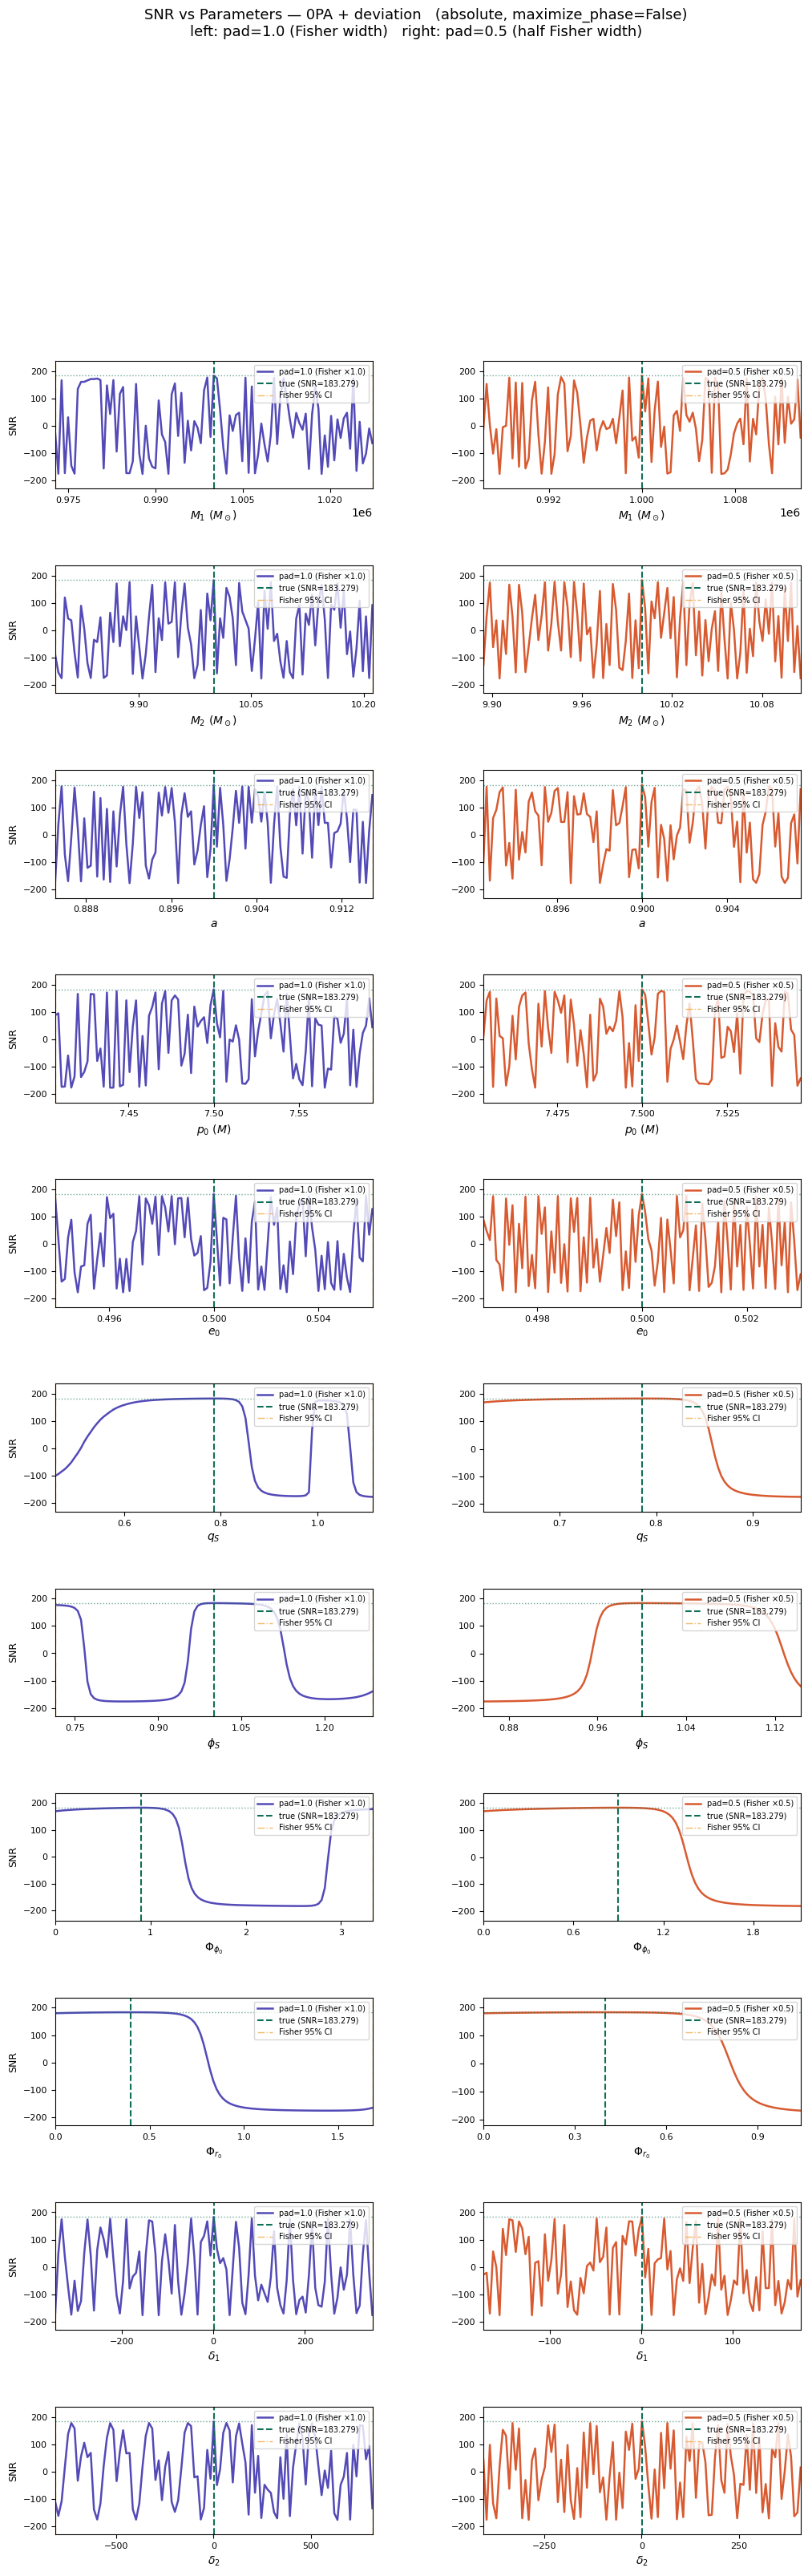

In [14]:
from matplotlib.gridspec import GridSpec

# ── Parameter setup ────────────────────────────────────────────────────────────
param_names_label = [r'$M_1\ (M_\odot)$', r'$M_2\ (M_\odot)$', r'$a$',
    r'$p_0\ (M)$', r'$e_0$', r'$q_S$', r'$\phi_S$', r'$\Phi_{\phi_0}$', r'$\Phi_{r_0}$',
    r'$\delta_1$', r'$\delta_2$']

x_best_fit_0PA_dev =  [1000000.0, 10.000000009924808, 0.8999997959803092, 7.499999983316402, 0.5000000389251131, 0.7853981634909842, 0.9999999999362225, 0.9000000000576618, 0.3999999999899322, 1.0000000307877215, 0.9999998929309868]
add_kwargs = {'chi2': 0,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': x_best_fit_0PA_dev[-2], 'dev_2': x_best_fit_0PA_dev[-1]}


bounds_0PA_dev = [(np.float64(972783.7747003845), np.float64(1027216.2252996155)), (np.float64(9.78865540617071), np.float64(10.211344613678905)), (np.float64(0.8850946334688392), np.float64(0.9149049584917792)), (np.float64(7.406901354103407), np.float64(7.593098612529397)), (np.float64(0.4939408492678258), np.float64(0.5060592285824005)), (np.float64(0.45752189956879313), np.float64(1.1132744274131754)), (np.float64(0.7145176797837784), np.float64(1.2854823200886665)), (np.float64(-1.5285045132925879), np.float64(3.3285045134079114)), (np.float64(-0.8803155012476351), np.float64(1.6803155012274995)), (np.float64(-345.7156128005072), np.float64(347.7156128620827)), (np.float64(-813.5354861510044), np.float64(815.5354859368664))]

PARAM_BOUNDS = [
    (None, None),
    (None, None),
    (-0.9999, 0.9999),
    (1.0, None),
    (0.0, 0.9999),
    (0.0, np.pi),
    (0.0, 2*np.pi),
    (0.0, 2*np.pi),
    (0.0, 2*np.pi),
    (None, None),
    (None, None),
]

fixed = {
    'waveform_response': ctx['waveform_response'],
    'PSD':               ctx['PSD_funcs'],
    'dt':                ctx['dt'],
    'T':                 ctx['T'],
    'N_fiducial':        ctx['N_fiducial'],
    'waveform_true_fft': ctx['waveform_true_fft'],
    'xp':                np,
    'delta_f':           ctx['delta_f'],
    'use_gpu':           True,
}

N_PARAMS    = len(x_best_fit_0PA_dev)
N_POINTS    = 100
# pad=1.0 → window = full Fisher width centred on true point
# pad=0.5 → window = half Fisher width (zoomed in)
PAD_FACTORS = [1.0, 0.5]


# ── Grid builder — true point always an exact node ─────────────────────────────
def make_grid(idx, pad, n_points=N_POINTS):
    lo, hi   = bounds_0PA_dev[idx]
    half     = (hi - lo) / 2.0
    true_val = x_best_fit_0PA_dev[idx]

    raw_lo = true_val - pad * half
    raw_hi = true_val + pad * half

    phys_lo, phys_hi = PARAM_BOUNDS[idx]
    if phys_lo is not None:
        raw_lo = max(raw_lo, phys_lo)
    if phys_hi is not None:
        raw_hi = min(raw_hi, phys_hi)

    frac_left = (true_val - raw_lo) / (raw_hi - raw_lo)
    n_left    = max(2, round(n_points * frac_left))
    n_right   = max(2, n_points - n_left + 1)

    left  = np.linspace(raw_lo,   true_val, n_left)
    right = np.linspace(true_val, raw_hi,   n_right)

    return np.concatenate([left, right[1:]])


# ── SNR profile ────────────────────────────────────────────────────────────────
def compute_snr_profile(idx, pad, n_points=N_POINTS):
    grid = make_grid(idx, pad, n_points)
    snr  = np.empty(len(grid))

    theta = list(x_best_fit_0PA_dev)
    for k, x in enumerate(grid):
        theta[idx] = x
        m1, m2, a, p0, e0, qS, phiS, Phi_phi0, Phi_r0, dev_1, dev_2 = theta
        # dev_1/dev_2 updated per iteration so varying them sweeps correctly
        add_kwargs = {'chi2': 0.0, 'evolve_1PA': True, 'evolve_primary': False,
                      'evolve_2PA': False, 'deviation_included': True,
                      'dev_1': dev_1, 'dev_2': dev_2}
        snr[k] = calculate_detection_snr_0pa_vs_1pa(
            m1, m2, a, p0, e0, ctx['Y0'], ctx['dist'], qS, phiS, ctx['qK'], ctx['phiK'],
            Phi_phi0, ctx['Phi_theta0'], Phi_r0, add_kwargs,
            maximize_phase=False,
            **fixed)

    true_idx = np.argmin(np.abs(grid - x_best_fit_0PA_dev[idx]))
    snr_true = snr[true_idx]

    return grid, snr, snr_true


# ── Plotting ───────────────────────────────────────────────────────────────────
PAD_COLORS = ['#534AB7', '#D85A30']
PAD_LABELS = [f'pad={p} (Fisher ×{p})' for p in PAD_FACTORS]

def plot_snr_profiles():
    ncols = len(PAD_FACTORS)   # 2 columns: wide | zoomed
    nrows = N_PARAMS            # 11 rows, one per parameter

    fig = plt.figure(figsize=(6 * ncols, 3.2 * nrows))
    gs  = GridSpec(nrows, ncols, figure=fig, hspace=0.6, wspace=0.35)

    for idx in range(N_PARAMS):
        for col, (pad, color, label) in enumerate(zip(PAD_FACTORS, PAD_COLORS, PAD_LABELS)):
            ax = fig.add_subplot(gs[idx, col])

            grid, snr, snr_true = compute_snr_profile(idx, pad)

            ax.plot(grid, snr, color=color, lw=1.8, label=label)

            # horizontal reference at true-point SNR
            ax.axhline(snr_true, color='#0F6E56', lw=1.0, ls=':', alpha=0.6)

            # vertical true-point marker
            ax.axvline(x_best_fit_0PA_dev[idx], color='#0F6E56',
                       lw=1.5, ls='--', label=f'true (SNR={snr_true:.3f})')

            # Fisher bounds as lines (visible at any zoom level)
            lo, hi = bounds_0PA_dev[idx]
            ax.axvline(lo, color='#EF9F27', lw=1.0, ls='-.', alpha=0.7)
            ax.axvline(hi, color='#EF9F27', lw=1.0, ls='-.', alpha=0.7,
                       label='Fisher 95% CI')

            # x-axis limits follow the grid exactly — different per pad and per panel
            ax.set_xlim(grid[0], grid[-1])

            # y-axis tight around SNR range in this window
            snr_min, snr_max = np.min(snr), np.max(snr)
            margin = (snr_max - snr_min) * 0.15 if snr_max > snr_min else abs(snr_true) * 0.01
            ax.set_ylim(snr_min - margin, snr_max + margin)

            if col == 0:
                ax.set_ylabel(r'SNR', fontsize=9)

            ax.set_xlabel(param_names_label[idx], fontsize=10)
            ax.tick_params(labelsize=8)
            ax.xaxis.set_major_locator(plt.MaxNLocator(4))
            ax.yaxis.set_major_locator(plt.MaxNLocator(5))
            ax.ticklabel_format(style='sci', axis='both', scilimits=(-3, 4), useOffset=True)
            ax.legend(fontsize=7, loc='upper right')

    fig.suptitle('SNR vs Parameters — 0PA + deviation   (absolute, maximize_phase=False)\n'
                 'left: pad=1.0 (Fisher width)   right: pad=0.5 (half Fisher width)',
                 fontsize=13, y=1.005)
    plt.tight_layout()
    plt.show()


if __name__ == '__main__':
    plot_snr_profiles()

In [27]:
fixed["waveform_true_fft"]= ctx['waveform_true_fft'][0:2]

In [28]:
fixed["PSD"]= ctx['PSD_funcs'][0:2]
fixed["waveform_true_fft"].shape

(2, 1577907)

/tmp/ipykernel_1308345/1346860421.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


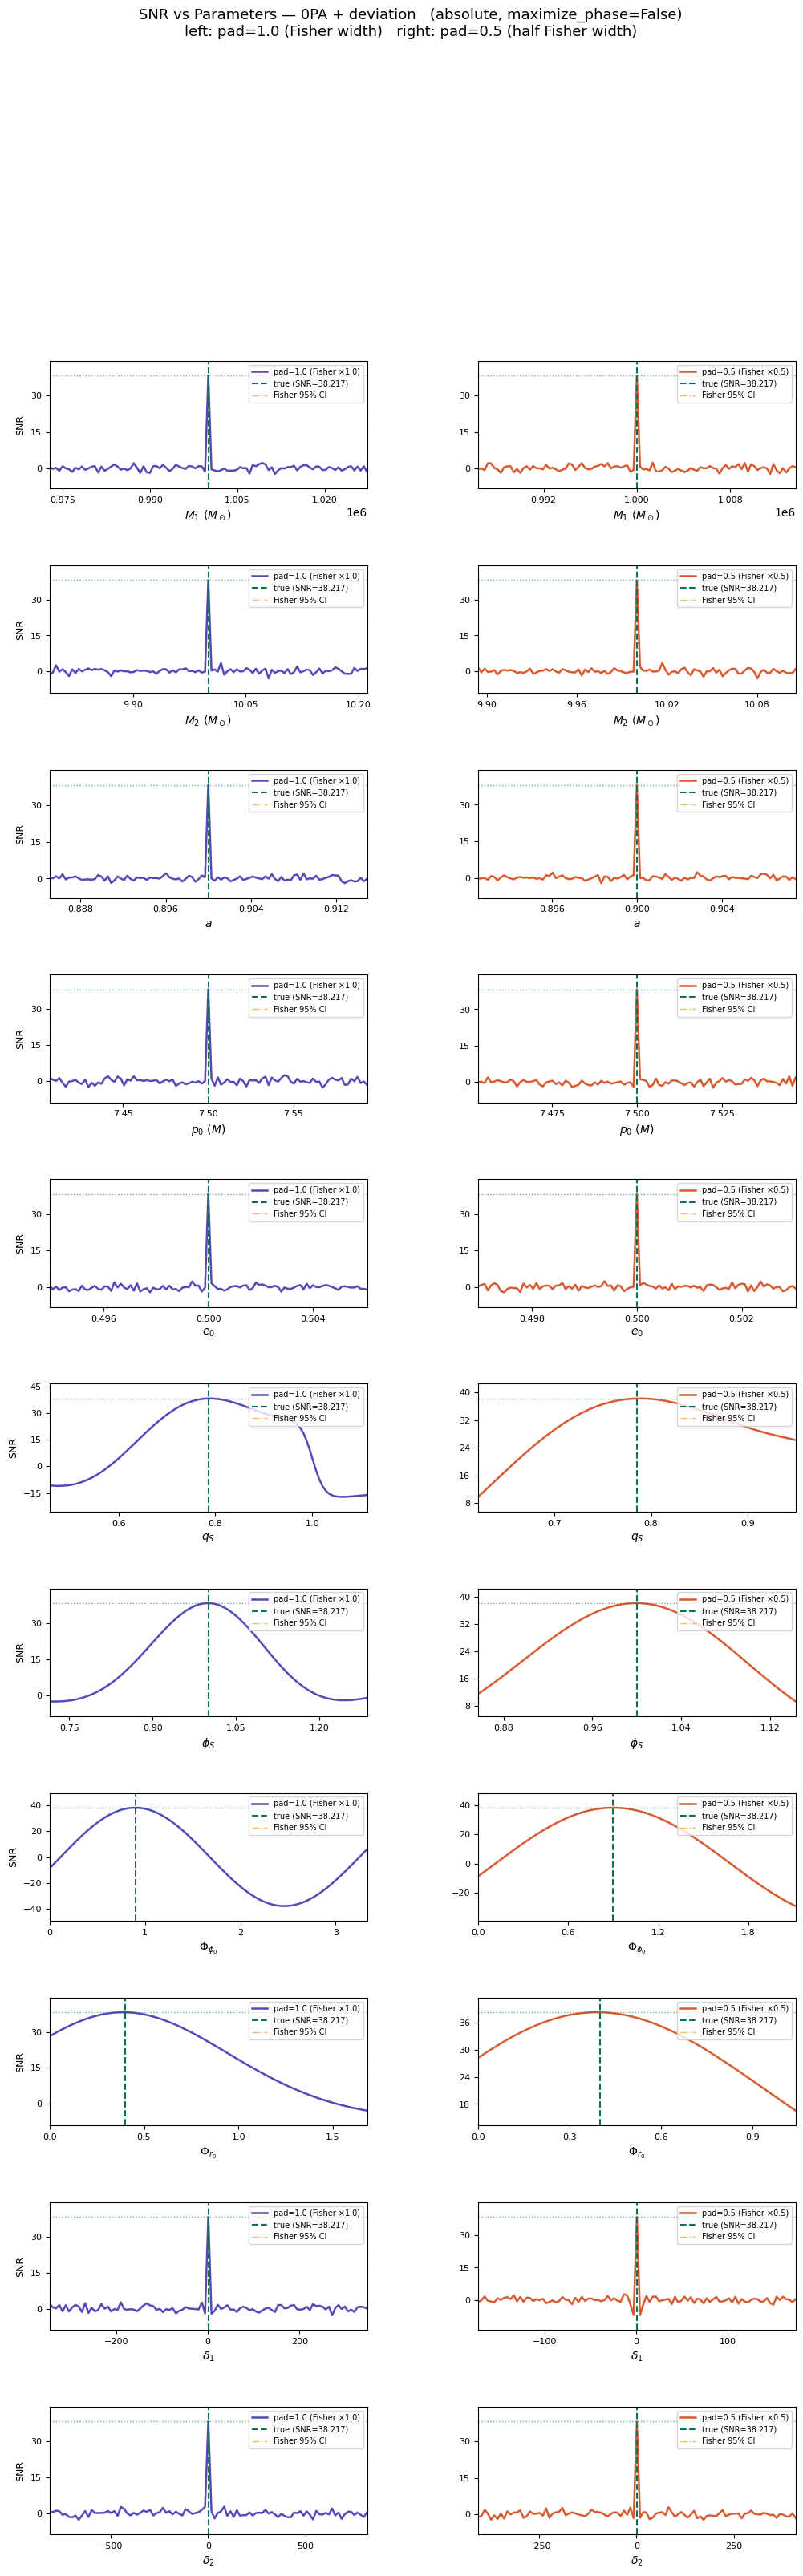

In [29]:
from matplotlib.gridspec import GridSpec

# ── Parameter setup ────────────────────────────────────────────────────────────
param_names_label = [r'$M_1\ (M_\odot)$', r'$M_2\ (M_\odot)$', r'$a$',
    r'$p_0\ (M)$', r'$e_0$', r'$q_S$', r'$\phi_S$', r'$\Phi_{\phi_0}$', r'$\Phi_{r_0}$',
    r'$\delta_1$', r'$\delta_2$']

x_best_fit_0PA_dev =  [1000000.0, 10.000000009924808, 0.8999997959803092, 7.499999983316402, 0.5000000389251131, 0.7853981634909842, 0.9999999999362225, 0.9000000000576618, 0.3999999999899322, 1.0000000307877215, 0.9999998929309868]
add_kwargs = {'chi2': 0,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': x_best_fit_0PA_dev[-2], 'dev_2': x_best_fit_0PA_dev[-1]}


bounds_0PA_dev = [(np.float64(972783.7747003845), np.float64(1027216.2252996155)), (np.float64(9.78865540617071), np.float64(10.211344613678905)), (np.float64(0.8850946334688392), np.float64(0.9149049584917792)), (np.float64(7.406901354103407), np.float64(7.593098612529397)), (np.float64(0.4939408492678258), np.float64(0.5060592285824005)), (np.float64(0.45752189956879313), np.float64(1.1132744274131754)), (np.float64(0.7145176797837784), np.float64(1.2854823200886665)), (np.float64(-1.5285045132925879), np.float64(3.3285045134079114)), (np.float64(-0.8803155012476351), np.float64(1.6803155012274995)), (np.float64(-345.7156128005072), np.float64(347.7156128620827)), (np.float64(-813.5354861510044), np.float64(815.5354859368664))]

PARAM_BOUNDS = [
    (None, None),
    (None, None),
    (-0.9999, 0.9999),
    (1.0, None),
    (0.0, 0.9999),
    (0.0, np.pi),
    (0.0, 2*np.pi),
    (0.0, 2*np.pi),
    (0.0, 2*np.pi),
    (None, None),
    (None, None),
]

# fixed = {
#     'waveform_response': ctx['waveform_response'],
#     'PSD':               ctx['PSD_funcs'],
#     'dt':                ctx['dt'],
#     'T':                 ctx['T'],
#     'N_fiducial':        ctx['N_fiducial'],
#     'waveform_true_fft': ctx['waveform_true_fft'],
#     'xp':                np,
#     'delta_f':           ctx['delta_f'],
#     'use_gpu':           True,
# }

N_PARAMS    = len(x_best_fit_0PA_dev)
N_POINTS    = 100
# pad=1.0 → window = full Fisher width centred on true point
# pad=0.5 → window = half Fisher width (zoomed in)
PAD_FACTORS = [1.0, 0.5]


# ── Grid builder — true point always an exact node ─────────────────────────────
def make_grid(idx, pad, n_points=N_POINTS):
    lo, hi   = bounds_0PA_dev[idx]
    half     = (hi - lo) / 2.0
    true_val = x_best_fit_0PA_dev[idx]

    raw_lo = true_val - pad * half
    raw_hi = true_val + pad * half

    phys_lo, phys_hi = PARAM_BOUNDS[idx]
    if phys_lo is not None:
        raw_lo = max(raw_lo, phys_lo)
    if phys_hi is not None:
        raw_hi = min(raw_hi, phys_hi)

    frac_left = (true_val - raw_lo) / (raw_hi - raw_lo)
    n_left    = max(2, round(n_points * frac_left))
    n_right   = max(2, n_points - n_left + 1)

    left  = np.linspace(raw_lo,   true_val, n_left)
    right = np.linspace(true_val, raw_hi,   n_right)

    return np.concatenate([left, right[1:]])


# ── SNR profile ────────────────────────────────────────────────────────────────
def compute_snr_profile(idx, pad, n_points=N_POINTS):
    grid = make_grid(idx, pad, n_points)
    snr  = np.empty(len(grid))

    theta = list(x_best_fit_0PA_dev)
    for k, x in enumerate(grid):
        theta[idx] = x
        m1, m2, a, p0, e0, qS, phiS, Phi_phi0, Phi_r0, dev_1, dev_2 = theta
        # dev_1/dev_2 updated per iteration so varying them sweeps correctly
        add_kwargs = {'chi2': 0.0, 'evolve_1PA': True, 'evolve_primary': False,
                      'evolve_2PA': False, 'deviation_included': True,
                      'dev_1': dev_1, 'dev_2': dev_2}
        snr[k] = calculate_detection_snr_0pa_vs_1pa(
            m1, m2, a, p0, e0, ctx['Y0'], ctx['dist'], qS, phiS, ctx['qK'], ctx['phiK'],
            Phi_phi0, ctx['Phi_theta0'], Phi_r0, add_kwargs,
            maximize_phase=False,
            **fixed)

    true_idx = np.argmin(np.abs(grid - x_best_fit_0PA_dev[idx]))
    snr_true = snr[true_idx]

    return grid, snr, snr_true


# ── Plotting ───────────────────────────────────────────────────────────────────
PAD_COLORS = ['#534AB7', '#D85A30']
PAD_LABELS = [f'pad={p} (Fisher ×{p})' for p in PAD_FACTORS]

def plot_snr_profiles():
    ncols = len(PAD_FACTORS)   # 2 columns: wide | zoomed
    nrows = N_PARAMS            # 11 rows, one per parameter

    fig = plt.figure(figsize=(6 * ncols, 3.2 * nrows))
    gs  = GridSpec(nrows, ncols, figure=fig, hspace=0.6, wspace=0.35)

    for idx in range(N_PARAMS):
        for col, (pad, color, label) in enumerate(zip(PAD_FACTORS, PAD_COLORS, PAD_LABELS)):
            ax = fig.add_subplot(gs[idx, col])

            grid, snr, snr_true = compute_snr_profile(idx, pad)

            ax.plot(grid, snr, color=color, lw=1.8, label=label)

            # horizontal reference at true-point SNR
            ax.axhline(snr_true, color='#0F6E56', lw=1.0, ls=':', alpha=0.6)

            # vertical true-point marker
            ax.axvline(x_best_fit_0PA_dev[idx], color='#0F6E56',
                       lw=1.5, ls='--', label=f'true (SNR={snr_true:.3f})')

            # Fisher bounds as lines (visible at any zoom level)
            lo, hi = bounds_0PA_dev[idx]
            ax.axvline(lo, color='#EF9F27', lw=1.0, ls='-.', alpha=0.7)
            ax.axvline(hi, color='#EF9F27', lw=1.0, ls='-.', alpha=0.7,
                       label='Fisher 95% CI')

            # x-axis limits follow the grid exactly — different per pad and per panel
            ax.set_xlim(grid[0], grid[-1])

            # y-axis tight around SNR range in this window
            snr_min, snr_max = np.min(snr), np.max(snr)
            margin = (snr_max - snr_min) * 0.15 if snr_max > snr_min else abs(snr_true) * 0.01
            ax.set_ylim(snr_min - margin, snr_max + margin)

            if col == 0:
                ax.set_ylabel(r'SNR', fontsize=9)

            ax.set_xlabel(param_names_label[idx], fontsize=10)
            ax.tick_params(labelsize=8)
            ax.xaxis.set_major_locator(plt.MaxNLocator(4))
            ax.yaxis.set_major_locator(plt.MaxNLocator(5))
            ax.ticklabel_format(style='sci', axis='both', scilimits=(-3, 4), useOffset=True)
            ax.legend(fontsize=7, loc='upper right')

    fig.suptitle('SNR vs Parameters — 0PA + deviation   (absolute, maximize_phase=False)\n'
                 'left: pad=1.0 (Fisher width)   right: pad=0.5 (half Fisher width)',
                 fontsize=13, y=1.005)
    plt.tight_layout()
    plt.show()


if __name__ == '__main__':
    plot_snr_profiles()

In [30]:
use_gpu = True
channels = [A1TDISens, E1TDISens, T1TDISens]
noise_kwargs = [{"sens_fn": ch} for ch in channels]

sef = StableEMRIFisher(waveform_class=SuperKludgeWaveform,
                       waveform_class_kwargs = dict(sum_kwargs=dict(pad_output=False, odd_len=True)),
                       waveform_generator = GenerateEMRIWaveform,
                       waveform_generator_kwargs= dict(return_list=False),
                       ResponseWrapper=ResponseWrapper,
                       ResponseWrapper_kwargs = dict(Tobs=ctx['T'],
                                                    t0=10000.0,
                                                    dt=ctx['dt'],
                                                    index_lambda=8,
                                                    index_beta=7,
                                                    flip_hx=True,
                                                    is_ecliptic_latitude=False,
                                                    remove_garbage="zero",
                                                    orbits=EqualArmlengthOrbits(use_gpu=use_gpu),
                                                    force_backend = "cuda12x" if use_gpu else "cpu",
                                                    order=20,
                                                    tdi="1st generation",
                                                    tdi_chan="AET"),
                       stats_for_nerds = True, use_gpu = use_gpu,
                       deriv_type='stable',
                       noise_model=get_sensitivity,
                       noise_kwargs=noise_kwargs,
                       channels=channels,
                       T = ctx['T'], dt = ctx['dt'],
                       stability_plot = False,
                       der_order = 10, Ndelta = 20,
                       plunge_check=True, return_derivatives=False
                       )
emri_kwargs = {"T":ctx['T'], "dt":ctx['dt']}



waveform shape: (3, 3155814)
wave ndim: 2
Computing SNR for parameters: (1000000.0, 10.000000009924808, 0.8999997959803092, 7.499999983316402, 0.5000000389251131, np.float64(1.0), np.float64(5.0), 0.7853981634909842, 0.9999999999362225, np.float64(1.0), np.float64(1.0471975511965976), 0.9000000000576618, np.float64(0.5), 0.3999999999899322, 0, True, False, False, True, 1.0000000307877215, 0.9999998929309868)
SNR:  178.55587744533676
Body is not plunging, Fisher should be stable.
waveform shape: (3, 3155814)
wave ndim: 2
Computing SNR for parameters: (1000000.0, 10.000000009924808, 0.8999997959803092, 7.499999983316402, 0.5000000389251131, np.float64(1.0), np.float64(5.0), 0.7853981634909842, 0.9999999999362225, np.float64(1.0), np.float64(1.0471975511965976), 0.9000000000576618, np.float64(0.5), 0.3999999999899322, 0, True, False, False, True, 1.0000000307877215, 0.9999998929309868)
Waveform Generated. SNR: 178.55587744533676
calculating stable deltas...
Gamma_ii for m1: 48959.95815054

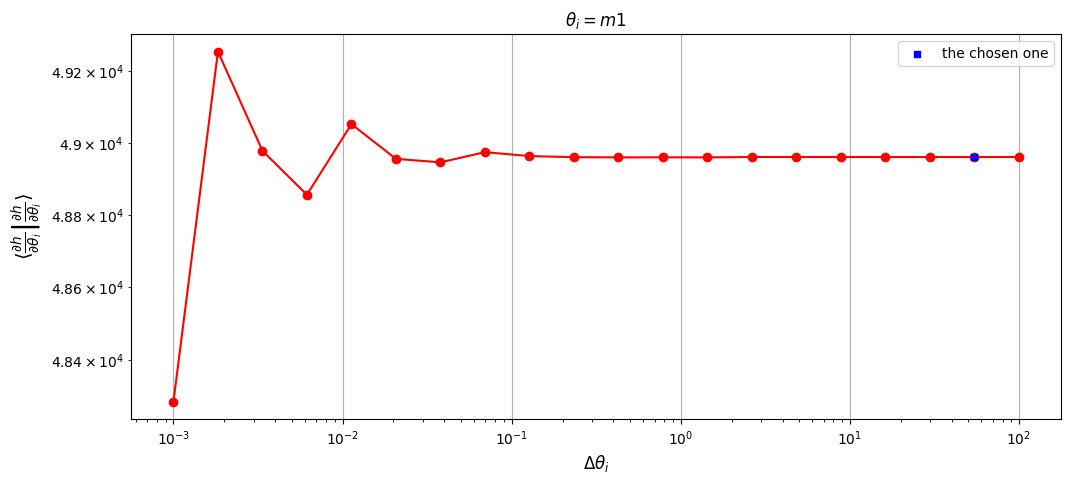

Gamma_ii for m2: 30138497503060.84
Gamma_ii for m2: 30138437938951.13
Gamma_ii for m2: 30138466435545.93
Gamma_ii for m2: 30138514893472.15
Gamma_ii for m2: 30138449483136.586
Gamma_ii for m2: 30138451236133.89
Gamma_ii for m2: 30138014252957.25
Gamma_ii for m2: 30138301139588.152
Gamma_ii for m2: 30139875271614.27
Gamma_ii for m2: 30136075959330.043
Gamma_ii for m2: 30134285934333.414
Gamma_ii for m2: 30144443000582.477
Gamma_ii for m2: 30171022417923.344
Gamma_ii for m2: 30102264124842.79
Gamma_ii for m2: 30126028175622.1
Gamma_ii for m2: 30365783243827.004
Gamma_ii for m2: 29878825403606.758
Gamma_ii for m2: 30181709206191.86
Gamma_ii for m2: 30872006325020.234
Gamma_ii for m2: 28480682089462.777
[np.float64(1.9763502618016054e-06), np.float64(9.455223895258246e-07), np.float64(1.607840545230241e-06), np.float64(2.1703284901600244e-06), np.float64(5.816481049251061e-08), np.float64(1.4499401751319652e-05), np.float64(9.519004723378516e-06), np.float64(5.222755608413897e-05), np.floa

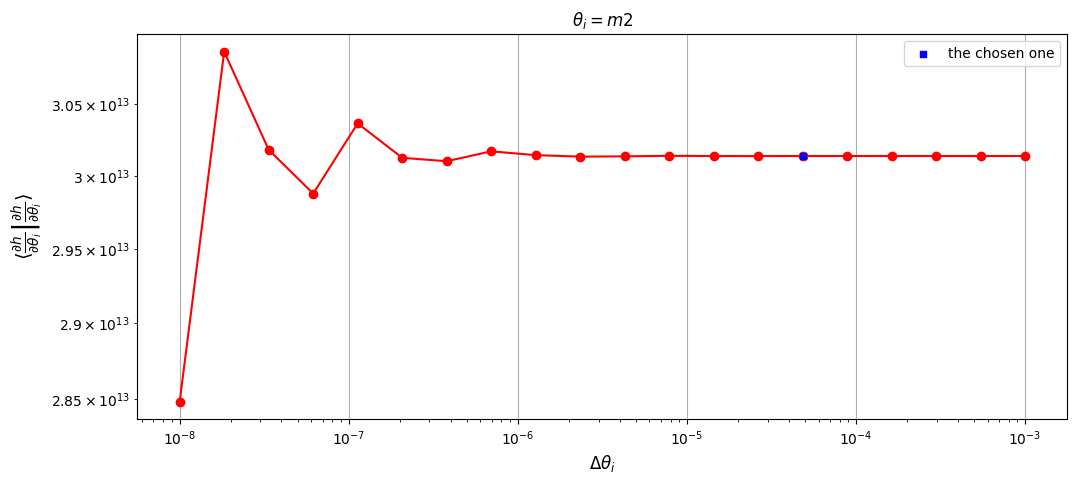

Gamma_ii for a: 2643634748162676.5
Gamma_ii for a: 2643637179195580.5
Gamma_ii for a: 2643628691751339.0
Gamma_ii for a: 2643632928680960.5
Gamma_ii for a: 2643618185010494.0
Gamma_ii for a: 2643656509608712.5
Gamma_ii for a: 2643534768566084.0
Gamma_ii for a: 2643675924307509.0
Gamma_ii for a: 2644239305011566.5
Gamma_ii for a: 2643834631823072.0
Gamma_ii for a: 2642367122254015.0
Gamma_ii for a: 2642443951453634.5
Gamma_ii for a: 2644517071315680.5
Gamma_ii for a: 2638442879143468.0
Gamma_ii for a: 2645420431571902.5
Gamma_ii for a: 2646069409403676.5
Gamma_ii for a: 2641077097698557.5
Gamma_ii for a: 2703210447528959.5
Gamma_ii for a: 2684096110339223.5
Gamma_ii for a: 2471996311673320.5
[np.float64(9.195788753204504e-07), np.float64(3.2105281153826777e-06), np.float64(1.6026921043134436e-06), np.float64(5.577080135890151e-06), np.float64(1.4496814574512338e-05), np.float64(4.6052370513944564e-05), np.float64(5.33937386678644e-05), np.float64(0.00021305965121603683), np.float64(0.00

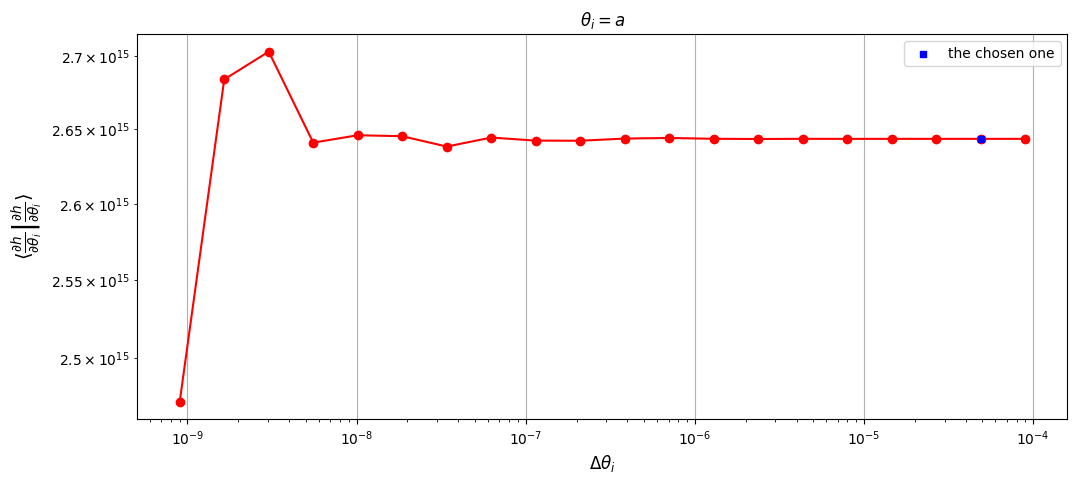

Gamma_ii for p0: 2415814468694563.5
Gamma_ii for p0: 2415813923553586.0
Gamma_ii for p0: 2415812896136304.5
Gamma_ii for p0: 2415813334233479.0
Gamma_ii for p0: 2415815245967245.5
Gamma_ii for p0: 2415820262819677.0
Gamma_ii for p0: 2415812978822050.5
Gamma_ii for p0: 2415813850452638.5
Gamma_ii for p0: 2415788673378040.5
Gamma_ii for p0: 2415801408524791.5
Gamma_ii for p0: 2415823642311824.0
Gamma_ii for p0: 2416075539216340.5
Gamma_ii for p0: 2416301732443383.5
Gamma_ii for p0: 2414429260925889.5
Gamma_ii for p0: 2417250918355201.0
Gamma_ii for p0: 2417672238612399.0
Gamma_ii for p0: 2417585006253449.5
Gamma_ii for p0: 2424066834144143.5
Gamma_ii for p0: 2399977442139678.5
Gamma_ii for p0: 2412551524405083.0
[np.float64(2.2565520141473264e-07), np.float64(4.252884331991045e-07), np.float64(1.8134562314559175e-07), np.float64(7.913410471646307e-07), np.float64(2.0766662606118186e-06), np.float64(3.015133079569626e-06), np.float64(3.60802049312155e-07), np.float64(1.0421886183775524e-0

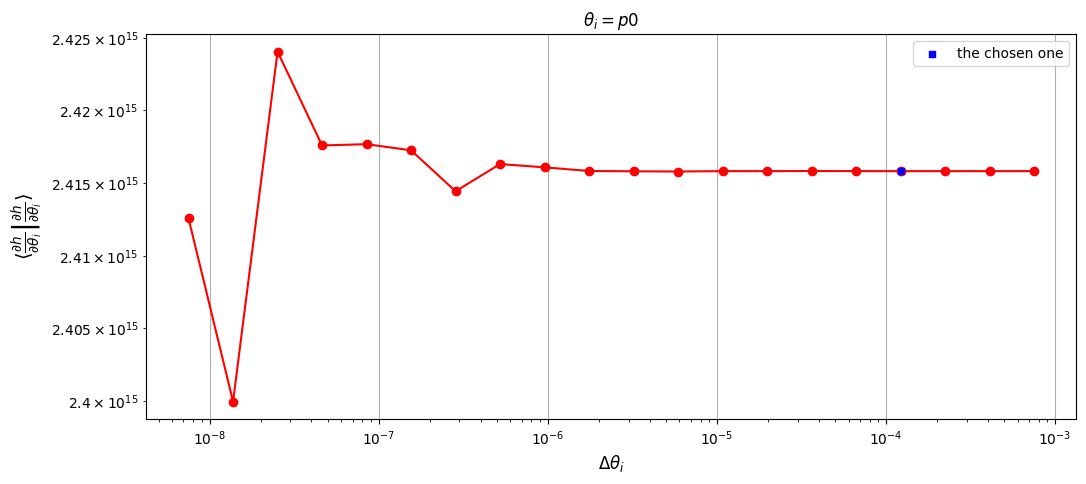

Gamma_ii for e0: 1.8286873696347172e+16
Gamma_ii for e0: 1.8286900428746696e+16
Gamma_ii for e0: 1.8286918330700584e+16
Gamma_ii for e0: 1.82869042572206e+16
Gamma_ii for e0: 1.828681028157574e+16
Gamma_ii for e0: 1.828690323099062e+16
Gamma_ii for e0: 1.8286912258742964e+16
Gamma_ii for e0: 1.8286722331143444e+16
Gamma_ii for e0: 1.8285898473872856e+16
Gamma_ii for e0: 1.8286283869195892e+16
Gamma_ii for e0: 1.8285120863919556e+16
Gamma_ii for e0: 1.8286989408034852e+16
Gamma_ii for e0: 1.8282520015371012e+16
Gamma_ii for e0: 1.829992396089614e+16
Gamma_ii for e0: 1.8280301569238324e+16
Gamma_ii for e0: 1.8285860744807436e+16
Gamma_ii for e0: 1.842902493172051e+16
Gamma_ii for e0: 1.8374599632439484e+16
Gamma_ii for e0: 1.8308764480201376e+16
Gamma_ii for e0: 1.98157133541861e+16
[np.float64(1.461833273941664e-06), np.float64(9.78948643191877e-07), np.float64(7.695933541317183e-07), np.float64(5.138985061527215e-06), np.float64(5.082840637690892e-06), np.float64(4.936728637544502e-07)

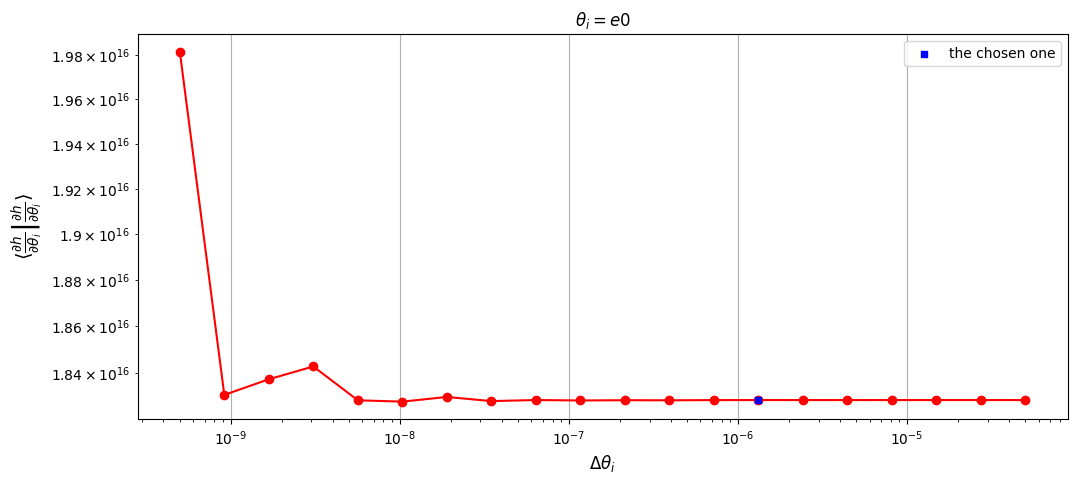

Gamma_ii for qS: 780857.1589856999
Gamma_ii for qS: 1412832.4072518353
Gamma_ii for qS: 1209279.3000109063
Gamma_ii for qS: 1226018.7468867972
Gamma_ii for qS: 1350990.7225785193
Gamma_ii for qS: 1219216.5006370235
Gamma_ii for qS: 1409701.8526580096
Gamma_ii for qS: 1553076.396082656
Gamma_ii for qS: 1378880.6260396438
Gamma_ii for qS: 1407721.0132837384
Gamma_ii for qS: 1397382.6966681213
Gamma_ii for qS: 1397460.9871337712
Gamma_ii for qS: 1396387.2864617945
Gamma_ii for qS: 1404674.1910364528
Gamma_ii for qS: 1364668.454908335
Gamma_ii for qS: 1365390.1432855744
Gamma_ii for qS: 1384466.7330368764
Gamma_ii for qS: 1388310.268671212
Gamma_ii for qS: 1386366.0537934715
Gamma_ii for qS: 1385719.1658362232
[np.float64(0.4473108381590845), np.float64(0.16832596674655162), np.float64(0.01365349993089181), np.float64(0.09250394810498683), np.float64(0.10808106835221276), np.float64(0.13512456670311085), np.float64(0.09231647830479027), np.float64(0.12633129130498347), np.float64(0.0204872

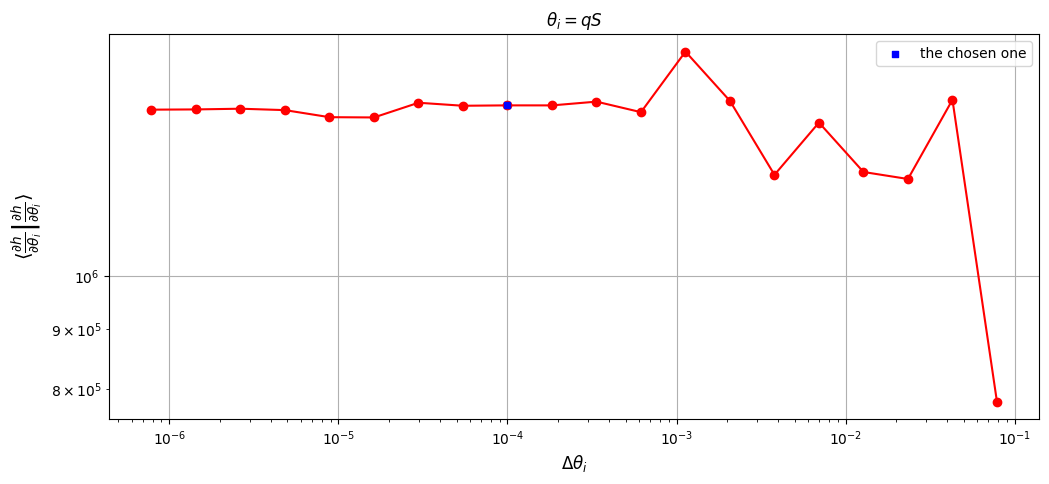

Gamma_ii for phiS: 6461019.31059205
Gamma_ii for phiS: 7089406.29206715
Gamma_ii for phiS: 7214417.745918447
Gamma_ii for phiS: 7216182.1319916975
Gamma_ii for phiS: 7120098.554624742
Gamma_ii for phiS: 7168419.400140614
Gamma_ii for phiS: 7150448.333380639
Gamma_ii for phiS: 7151174.100650026
Gamma_ii for phiS: 7148804.480966605
Gamma_ii for phiS: 7153242.907919128
Gamma_ii for phiS: 7151168.734538385
Gamma_ii for phiS: 7159203.993810145
Gamma_ii for phiS: 7150018.137600357
Gamma_ii for phiS: 7141865.663157419
Gamma_ii for phiS: 7191454.814508037
Gamma_ii for phiS: 7040584.172097931
Gamma_ii for phiS: 7039274.041030909
Gamma_ii for phiS: 7093984.528398108
Gamma_ii for phiS: 7126345.685383106
Gamma_ii for phiS: 7112079.406906363
[np.float64(0.08863746209301725), np.float64(0.017328003208855303), np.float64(0.0002445040938515427), np.float64(0.01349469766883298), np.float64(0.006740794981237357), np.float64(0.0025132783179595596), np.float64(0.00010148924626543081), np.float64(0.0003314

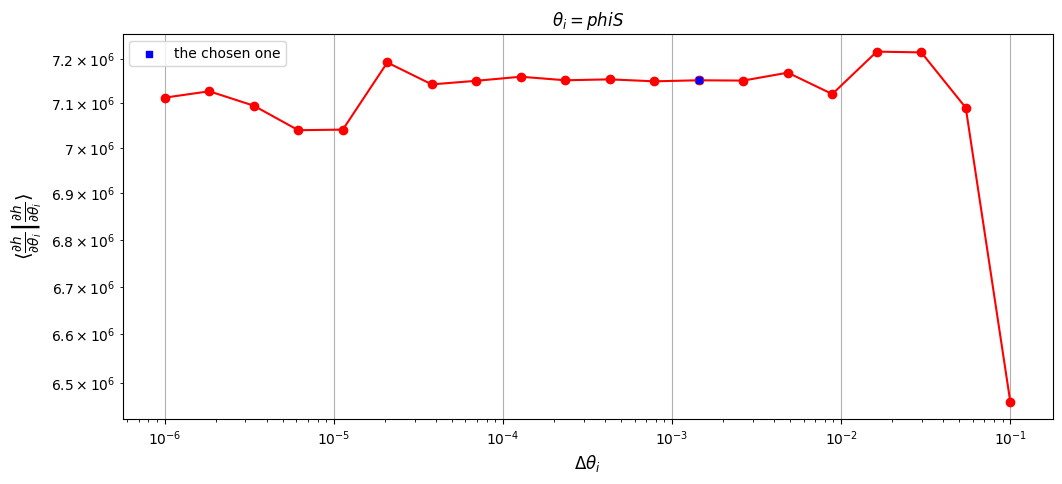

Gamma_ii for dev_1: 153455.48646781273
Gamma_ii for dev_1: 153455.16102724566
Gamma_ii for dev_1: 153418.1715186845
Gamma_ii for dev_1: 153543.91858907745
Gamma_ii for dev_1: 153430.6106315253
Gamma_ii for dev_1: 153536.45523158912
Gamma_ii for dev_1: 152752.93601614822
Gamma_ii for dev_1: 153623.91627367382
Gamma_ii for dev_1: 153409.78732535825
Gamma_ii for dev_1: 150152.24010609774
Gamma_ii for dev_1: 147446.94612047376
Gamma_ii for dev_1: 140132.96279163187
Gamma_ii for dev_1: 136177.04112990783
Gamma_ii for dev_1: 149916.16235790987
Gamma_ii for dev_1: 137369.79342117137
Gamma_ii for dev_1: 196635.44893552444
Gamma_ii for dev_1: 185282.53994952998
Gamma_ii for dev_1: 8773.435372504846
Gamma_ii for dev_1: 247179.1512581482
Gamma_ii for dev_1: 1187853.7067848358
[np.float64(2.1207534819655195e-06), np.float64(0.0002411025251767182), np.float64(0.0008189648378681419), np.float64(0.0007384964257507768), np.float64(0.000689377645876704), np.float64(0.00512932344133845), np.float64(0.00

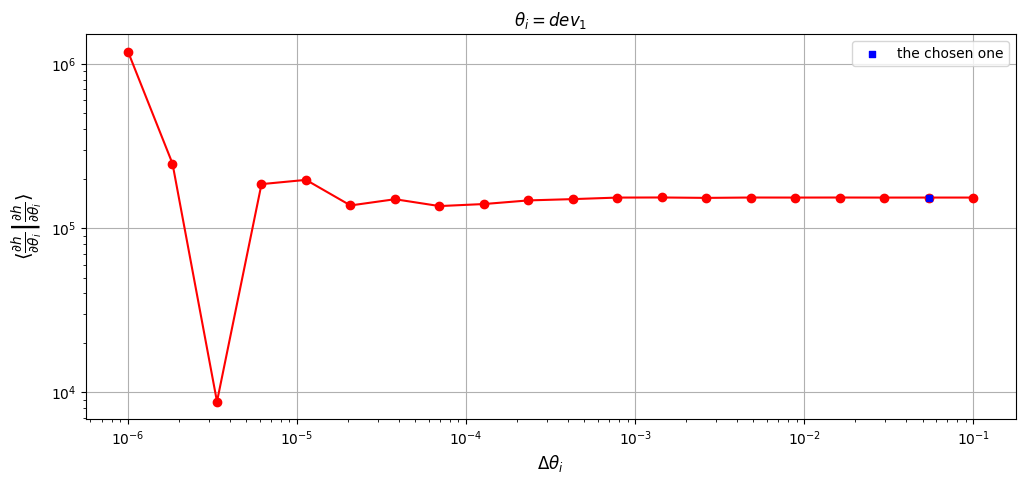

Gamma_ii for dev_2: 26020.3955162888
Gamma_ii for dev_2: 26034.078046908056
Gamma_ii for dev_2: 26039.497210946818
Gamma_ii for dev_2: 26054.425862702265
Gamma_ii for dev_2: 25977.04788655026
Gamma_ii for dev_2: 26163.844437756576
Gamma_ii for dev_2: 25819.53131812514
Gamma_ii for dev_2: 25870.387444343214
Gamma_ii for dev_2: 26490.68669420829
Gamma_ii for dev_2: 26571.17107154134
Gamma_ii for dev_2: 25963.57217237385
Gamma_ii for dev_2: 22053.454439327663
Gamma_ii for dev_2: 26599.563981377614
Gamma_ii for dev_2: 28043.81496254475
Gamma_ii for dev_2: 13677.115365459946
Gamma_ii for dev_2: 84541.394118125
Gamma_ii for dev_2: 36302.77993799447
Gamma_ii for dev_2: 40315.856174602886
Gamma_ii for dev_2: 69267.25931211654
Gamma_ii for dev_2: 774211.3926232829
[np.float64(0.0005255623262172707), np.float64(0.00020811323639856943), np.float64(0.0005729794943137595), np.float64(0.002978705528431822), np.float64(0.007139491738330081), np.float64(0.013335374503476355), np.float64(0.001965804583

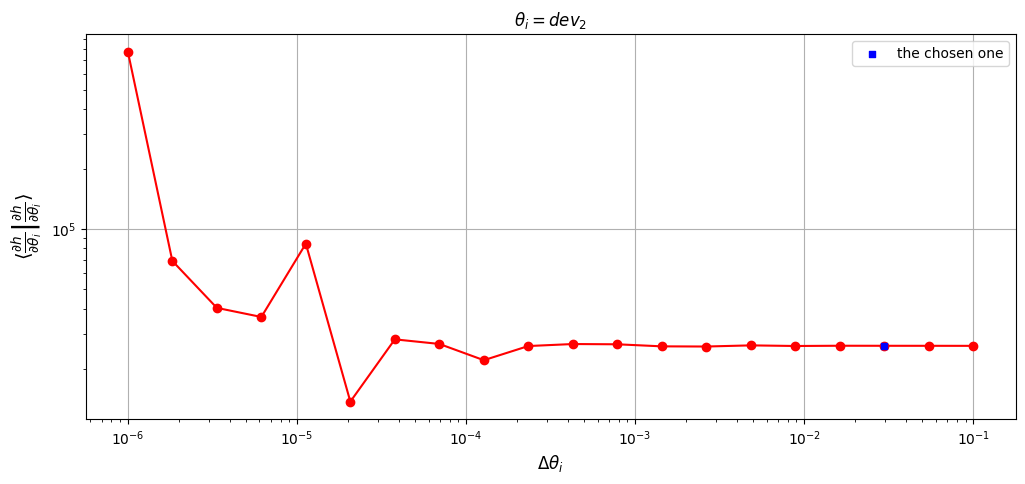

stable deltas: {'m1': 54.5559478116852, 'm2': 4.832930243368348e-05, 'a': 4.91003419000291e-05, 'p0': 0.00012178325516824985, 'e0': 1.3183255519971136e-06, 'qS': 0.00010008132335537417, 'phiS': 0.001438449888195922, 'Phi_phi0': 0.0, 'Phi_r0': 0.0, 'dev_1': 0.05455594949133851, 'dev_2': 0.029763511229563062}
Time taken to compute stable deltas is 53.8996741771698 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 2.9206125736236572 seconds


In [31]:
x_best_fit_0PA_dev =  [1000000.0, 10.000000009924808, 0.8999997959803092, 7.499999983316402, 0.5000000389251131, 0.7853981634909842, 0.9999999999362225, 0.9000000000576618, 0.3999999999899322, 1.0000000307877215, 0.9999998929309868]
add_kwargs_0PA_dev = {'chi2': 0,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': x_best_fit_0PA_dev[-2], 'dev_2': x_best_fit_0PA_dev[-1]}


m1, m2, a, p0, e0,qS,phiS,Phi_phi0,Phi_r0,dev_1,dev_2 = x_best_fit_0PA_dev
wave_params = [m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],qS,phiS, ctx['qK'], ctx['phiK'], 
                    Phi_phi0, ctx['Phi_theta0'], Phi_r0,add_kwargs_0PA_dev['chi2'],add_kwargs_0PA_dev['evolve_1PA'],
                    add_kwargs_0PA_dev['evolve_primary'],add_kwargs_0PA_dev['evolve_2PA'],
                      add_kwargs_0PA_dev['deviation_included'],add_kwargs_0PA_dev['dev_1'],add_kwargs_0PA_dev['dev_2']]


param_names_to_infer = ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0','dev_1','dev_2']  
dim = len(param_names_to_infer)
param_names = param_names_to_infer
SNR = sef.SNRcalc_SEF(*wave_params,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

param_dict = {
    'm1': wave_params[0],
    'm2': wave_params[1],
    'a': wave_params[2],
    'p0': wave_params[3],
    'e0': wave_params[4],
    'xI0': wave_params[5],
    'dist': wave_params[6],
    'qS': wave_params[7],
    'phiS': wave_params[8],
    'qK': wave_params[9],
    'phiK': wave_params[10],
    'Phi_phi0': wave_params[11],
    'Phi_theta0': wave_params[12],
    'Phi_r0': wave_params[13]}

Fisher_0PA_dev = sef(wave_params = param_dict,param_names=param_names, add_param_args=add_kwargs_0PA_dev,
            live_dangerously = False, stability_plot = True,der_order = 8, Ndelta = 20,return_derivatives = False)


In [33]:
np.save('Fisher_1PA_dev.npy', Fisher_0PA_dev)